In [16]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from spectral.io import load_graph_spectral, load_dmd, load_koopman, load_motion_prediction

RESULTS_DIR = Path("results/0103")  # change prefix as needed
FPS = 29.97

graph = load_graph_spectral(RESULTS_DIR / "graph_spectral.npz")
dmd = load_dmd(RESULTS_DIR / "dmd_observables.npz")
koopman = load_koopman(RESULTS_DIR / "koopman_observables.npz")

motion_path = RESULTS_DIR / "motion_prediction.npz"
if motion_path.exists():
    motion = load_motion_prediction(motion_path)
else:
    motion = None
    print("No motion_prediction.npz — run: python main.py motion -i <loc_vel_data.h5> -o", RESULTS_DIR)

num_frames = graph.spectral_vector.shape[0]
time_s = np.arange(num_frames) / FPS

print(f"Loaded {RESULTS_DIR.name}: {num_frames} frames ({num_frames / FPS / 60:.1f} min)")
print(f"Graph modes: {graph.spectral_vector.shape[1]}, DMD modes: {dmd.modal_energies.shape[1]}, Koopman dim: {koopman.lifted_state.shape[1]}")
if motion is not None:
    print(f"Motion labels: {motion.label_names}")

Loaded 0103: 24593 frames (13.7 min)
Graph modes: 69, DMD modes: 20, Koopman dim: 1558


In [17]:
def modal_entropy(energies: np.ndarray) -> np.ndarray:
    """Normalized modal entropy H(t) — PDF eq. 17 (preview for 5.5)."""
    e = np.asarray(energies, dtype=float)
    row_sum = np.nansum(e, axis=1, keepdims=True)
    p = np.divide(e, row_sum, out=np.zeros_like(e), where=row_sum > 0)
    p = np.clip(p, 1e-12, None)
    return -np.nansum(p * np.log(p), axis=1)


def rolling_std(x: np.ndarray, window: int) -> np.ndarray:
    """Rolling standard deviation (valid frames only)."""
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan)
    half = window // 2
    for t in range(len(x)):
        sl = x[max(0, t - half) : min(len(x), t + half + 1)]
        sl = sl[np.isfinite(sl)]
        if len(sl) >= 3:
            out[t] = sl.std()
    return out


def subsample(arr: np.ndarray, max_rows: int = 2000) -> tuple[np.ndarray, np.ndarray]:
    """Subsample rows for heatmaps when T is very large."""
    n = arr.shape[0]
    if n <= max_rows:
        return np.arange(n), arr
    idx = np.linspace(0, n - 1, max_rows, dtype=int)
    return idx, arr[idx]

## 5.2 Graph Laplacian spectra

Key Year-1 readout: **λ₂(t)** (algebraic connectivity) — high = cohesive school, low ≈ fragmentation.

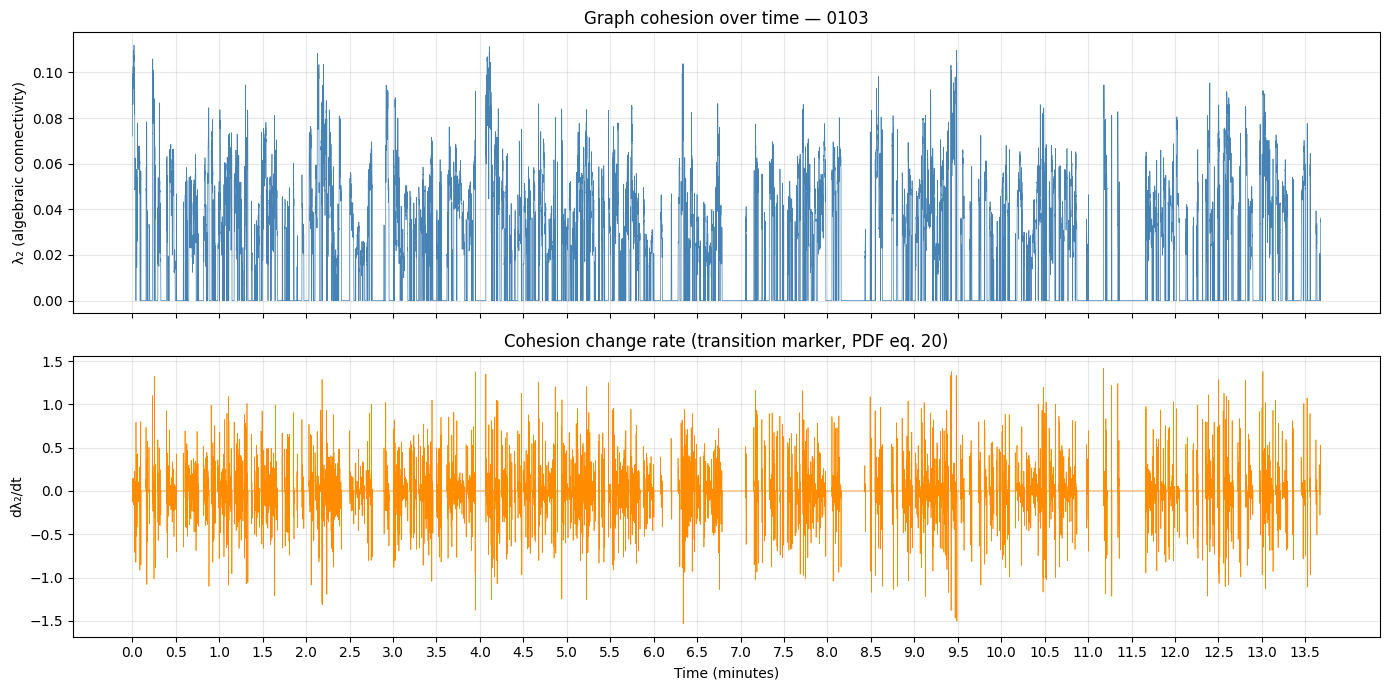

λ₂: mean=0.020, std=0.025, min=-0.000, max=0.112


In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

lambda2 = graph.algebraic_connectivity
minutes = time_s / 60

axes[0].plot(minutes, lambda2, lw=0.5, color="steelblue")
axes[0].set_ylabel("λ₂ (algebraic connectivity)")
axes[0].set_title(f"Graph cohesion over time — {RESULTS_DIR.name}")
axes[0].grid(alpha=0.3)

d_lambda2 = np.gradient(lambda2, dmd.dt)
axes[1].plot(minutes, d_lambda2, lw=0.5, color="darkorange")
axes[1].set_ylabel("dλ₂/dt")
axes[1].set_xlabel("Time (minutes)")
axes[1].set_title("Cohesion change rate (transition marker, PDF eq. 20)")
axes[1].grid(alpha=0.3)

# Set x ticks every half a minute
import math

start_min = minutes[0]
end_min = minutes[-1]
half_min_ticks = np.arange(math.ceil(start_min * 2) / 2, end_min + 0.25, 0.5)
axes[-1].set_xticks(half_min_ticks)
axes[-1].set_xticklabels([f"{tick:.1f}" for tick in half_min_ticks])

plt.tight_layout()
plt.show()

print(f"λ₂: mean={np.nanmean(lambda2):.3f}, std={np.nanstd(lambda2):.3f}, min={np.nanmin(lambda2):.3f}, max={np.nanmax(lambda2):.3f}")

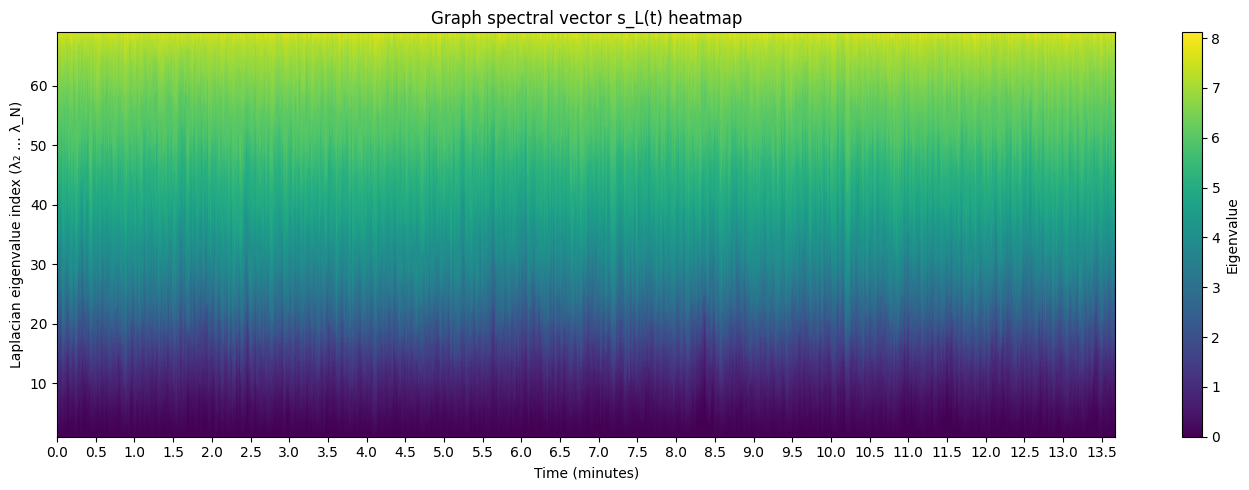

In [19]:
import math

idx, s_l_sub = subsample(graph.spectral_vector)
t_sub = time_s[idx] / 60

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(
    s_l_sub.T,
    aspect="auto",
    origin="lower",
    extent=[t_sub[0], t_sub[-1], 1, s_l_sub.shape[1]],
    cmap="viridis",
)
ax.set_xlabel("Time (minutes)")
ax.set_ylabel("Laplacian eigenvalue index (λ₂ … λ_N)")
ax.set_title("Graph spectral vector s_L(t) heatmap")

# Set x ticks every half a minute
start_min = t_sub[0]
end_min = t_sub[-1]
half_min_ticks = np.arange(math.ceil(start_min * 2) / 2, end_min + 0.25, 0.5)
ax.set_xticks(half_min_ticks)
ax.set_xticklabels([f"{tick:.1f}" for tick in half_min_ticks])

plt.colorbar(im, ax=ax, label="Eigenvalue")
plt.tight_layout()
plt.show()

## 5.3 DMD observables

Modal energies E_k(t) and entropy H(t) indicate mode competition (multistability preview, PDF eq. 16–17).

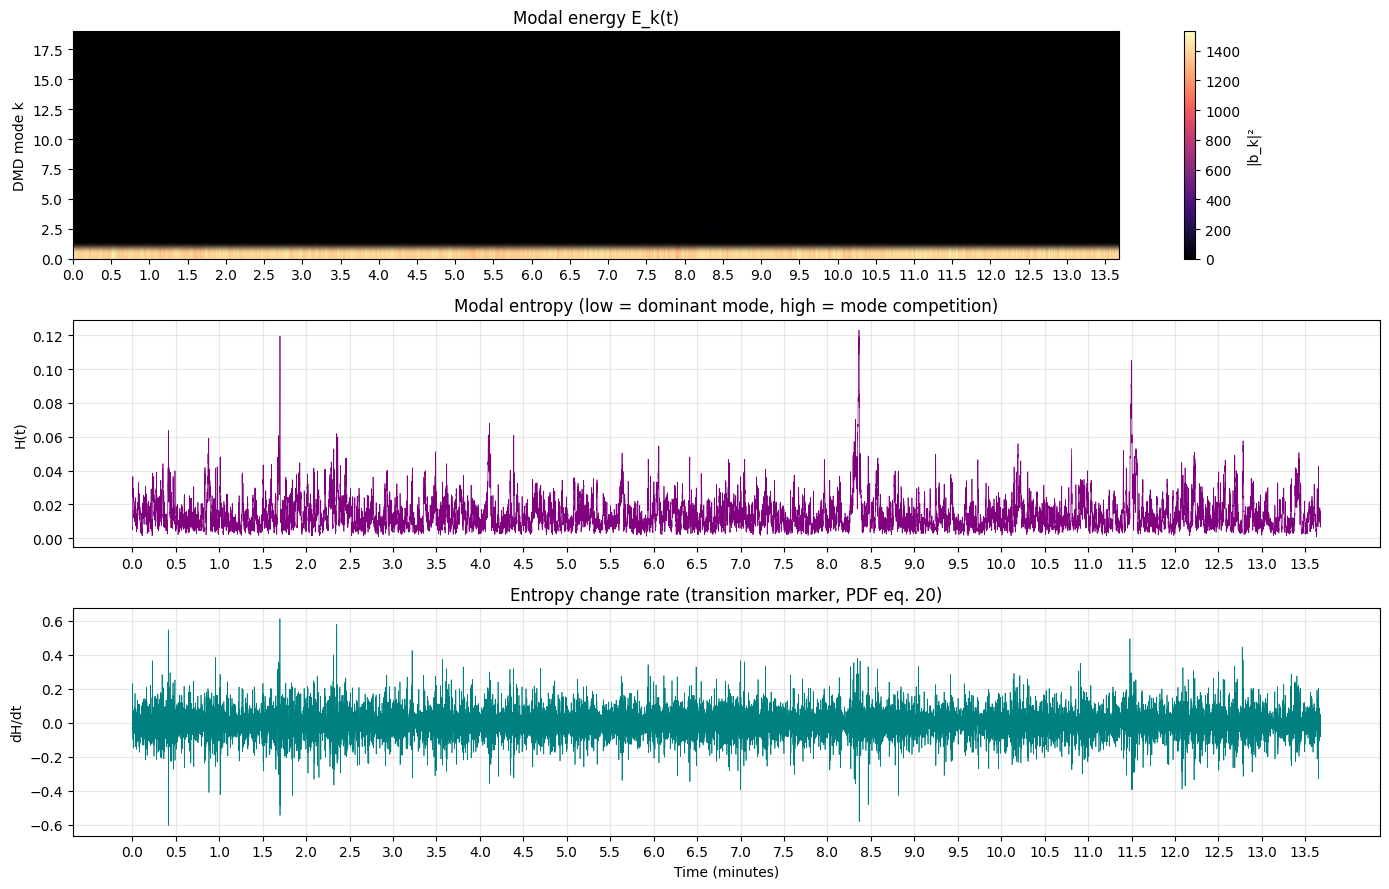

DMD eigenvalues μ: [0.99998331+0.j         0.55019013+0.j         0.96610215+0.j
 0.95050393+0.j         0.57831043+0.j         0.91336816+0.j
 0.61539497+0.j         0.88508931+0.j         0.85981255+0.j
 0.8405921 +0.j         0.65419446+0.j         0.67898464+0.j
 0.68479673+0.j         0.81036166+0.j         0.80183733+0.j
 0.7230255 +0.j         0.73530317+0.00338275j 0.73530317-0.00338275j
 0.75564209+0.00191922j 0.75564209-0.00191922j]
DMD frequencies ω: [ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.13787547 -0.13787547
  0.07611938 -0.07611938]
Modal entropy: mean=0.014, std=0.010


In [20]:
energies = dmd.modal_energies
entropy = modal_entropy(energies)
norm_energy = energies / np.nansum(energies, axis=1, keepdims=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 9))  # removed sharex

idx, e_sub = subsample(energies)
t_sub = time_s[idx] / 60
im = axes[0].imshow(
    e_sub.T,
    aspect="auto",
    origin="lower",
    extent=[t_sub[0], t_sub[-1], 0, e_sub.shape[1] - 1],
    cmap="magma",
)
axes[0].set_ylabel("DMD mode k")
axes[0].set_title("Modal energy E_k(t)")
plt.colorbar(im, ax=axes[0], label="|b_k|²")

# Set x ticks every half a minute for all subplots, and give xtick labels to the first subplot
start_min = t_sub[0]
end_min = t_sub[-1]
half_min_ticks = np.arange(math.ceil(start_min * 2) / 2, end_min + 0.25, 0.5)
for ax in axes:
    ax.set_xticks(half_min_ticks)
axes[0].set_xticklabels([f"{tick:.1f}" for tick in half_min_ticks])

axes[1].plot(time_s / 60, entropy, lw=0.5, color="purple")
axes[1].set_ylabel("H(t)")
axes[1].set_title("Modal entropy (low = dominant mode, high = mode competition)")
axes[1].grid(alpha=0.3)

dH = np.gradient(entropy, dmd.dt)
axes[2].plot(time_s / 60, dH, lw=0.5, color="teal")
axes[2].set_ylabel("dH/dt")
axes[2].set_xlabel("Time (minutes)")
axes[2].set_title("Entropy change rate (transition marker, PDF eq. 20)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("DMD eigenvalues μ:", dmd.eigenvalues)
print("DMD frequencies ω:", dmd.frequencies)
print(f"Modal entropy: mean={np.nanmean(entropy):.3f}, std={np.nanstd(entropy):.3f}")

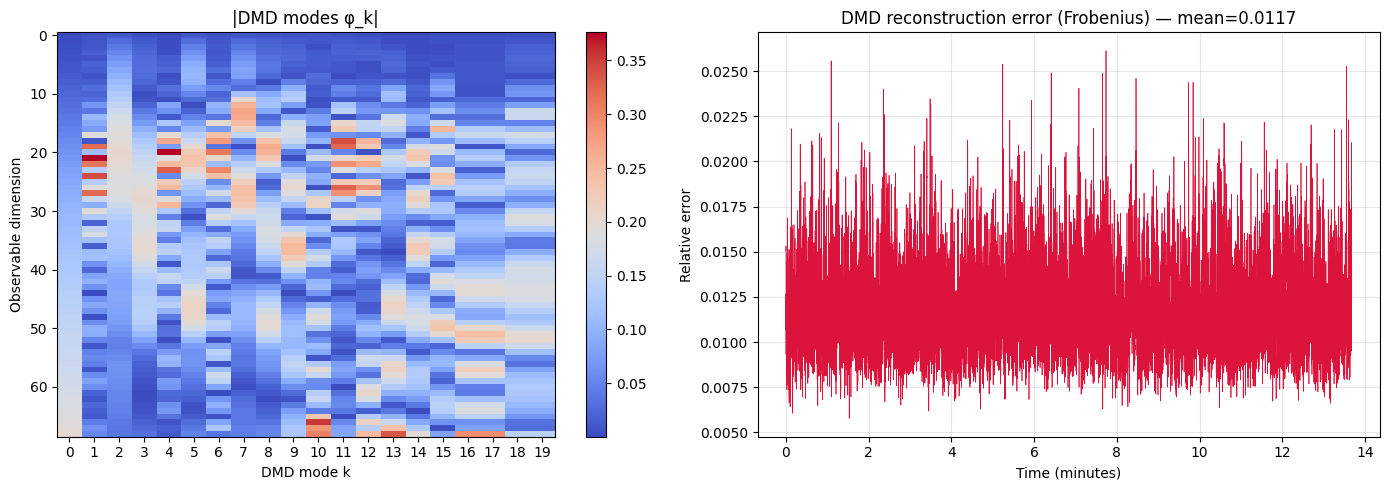

In [22]:
# DMD mode matrix and reconstruction quality (PDF eq. 25)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

num_modes = dmd.modes.shape[1]
im = axes[0].imshow(np.abs(dmd.modes), aspect="auto", cmap="coolwarm")
axes[0].set_xlabel("DMD mode k")
axes[0].set_ylabel("Observable dimension")
axes[0].set_title("|DMD modes φ_k|")
plt.colorbar(im, ax=axes[0])

# Set x-ticks to be integer DMD mode indices
axes[0].set_xticks(np.arange(num_modes))
axes[0].set_xticklabels([str(k) for k in range(num_modes)])

y = graph.spectral_vector
y_hat = dmd.reconstruction
valid = np.isfinite(y).all(axis=1) & np.isfinite(y_hat).all(axis=1)
err = np.linalg.norm(y[valid] - y_hat[valid], axis=1)
rel_err = err / np.linalg.norm(y[valid], axis=1)
axes[1].plot(time_s[valid] / 60, rel_err, lw=0.5, color="crimson")
axes[1].set_xlabel("Time (minutes)")
axes[1].set_ylabel("Relative error")
axes[1].set_title(f"DMD reconstruction error (Frobenius) — mean={np.mean(rel_err):.4f}")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5.4 Koopman observables

Lifted state z(t) and operator K — linearized dynamics in observable space (PDF eq. 13–14).

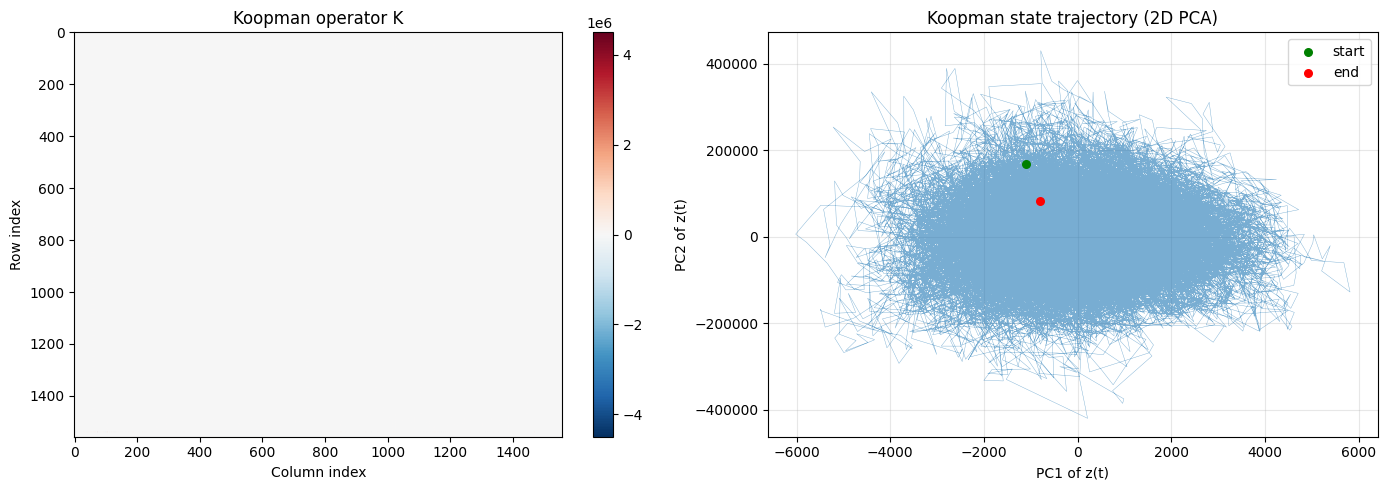

In [23]:
K = koopman.operator
z = koopman.lifted_state

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(K, aspect="auto", cmap="RdBu_r", vmin=-np.nanmax(np.abs(K)), vmax=np.nanmax(np.abs(K)))
axes[0].set_xlabel("Column index")
axes[0].set_ylabel("Row index")
axes[0].set_title("Koopman operator K")
plt.colorbar(im, ax=axes[0])

# PCA projection of z(t) for 2D trajectory view
z_valid = np.where(np.isfinite(z), z, np.nan)
z_centered = z_valid - np.nanmean(z_valid, axis=0)
cov = np.cov(z_centered, rowvar=False)
cov = np.where(np.isfinite(cov), cov, 0)
_, vecs = np.linalg.eigh(cov)
pc = z_centered @ vecs[:, -2:]
axes[1].plot(pc[:, 0], pc[:, 1], lw=0.3, alpha=0.6)
axes[1].scatter(pc[0, 0], pc[0, 1], c="green", s=30, label="start", zorder=5)
axes[1].scatter(pc[-1, 0], pc[-1, 1], c="red", s=30, label="end", zorder=5)
axes[1].set_xlabel("PC1 of z(t)")
axes[1].set_ylabel("PC2 of z(t)")
axes[1].set_title("Koopman state trajectory (2D PCA)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

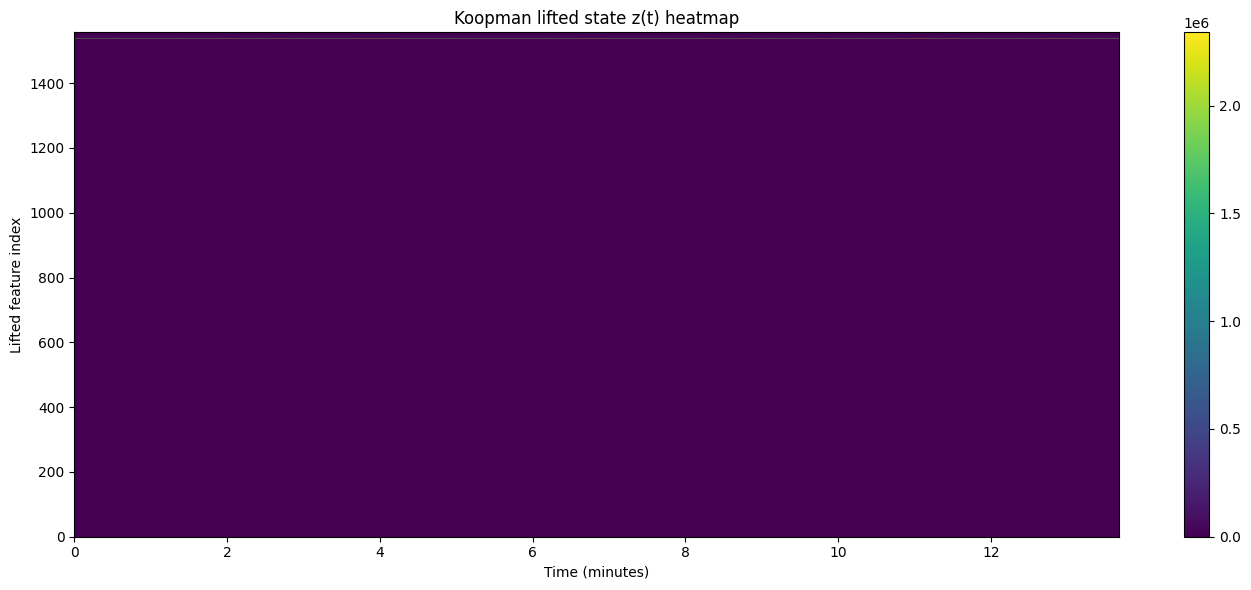

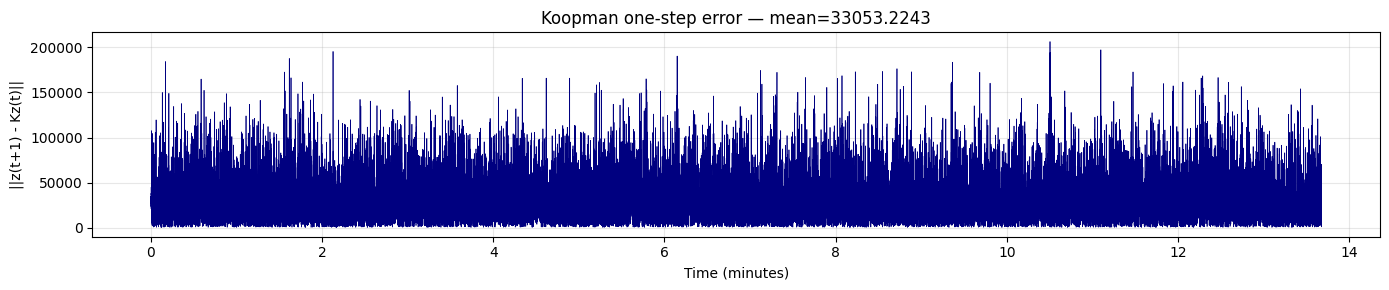

In [24]:
idx, z_sub = subsample(z)
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(
    z_sub.T,
    aspect="auto",
    origin="lower",
    extent=[time_s[idx[0]] / 60, time_s[idx[-1]] / 60, 0, z_sub.shape[1] - 1],
    cmap="viridis",
)
ax.set_xlabel("Time (minutes)")
ax.set_ylabel("Lifted feature index")
ax.set_title("Koopman lifted state z(t) heatmap")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# One-step prediction error
if koopman.one_step_prediction is not None and koopman.one_step_prediction.size:
    z_next_true = z[1:]
    z_next_pred = koopman.one_step_prediction
    valid_pairs = np.isfinite(z_next_true).all(axis=1) & np.isfinite(z_next_pred).all(axis=1)
    step_err = np.linalg.norm(z_next_true[valid_pairs] - z_next_pred[valid_pairs], axis=1)
    plt.figure(figsize=(14, 3))
    plt.plot(time_s[1:][valid_pairs] / 60, step_err, lw=0.5, color="navy")
    plt.xlabel("Time (minutes)")
    plt.ylabel("||z(t+1) - Kz(t)||")
    plt.title(f"Koopman one-step error — mean={np.mean(step_err):.4f}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Year 1 summary — stationary vs multistability proxies

Rolling stability of observables (PDF eq. 15 preview) and joint transition markers.

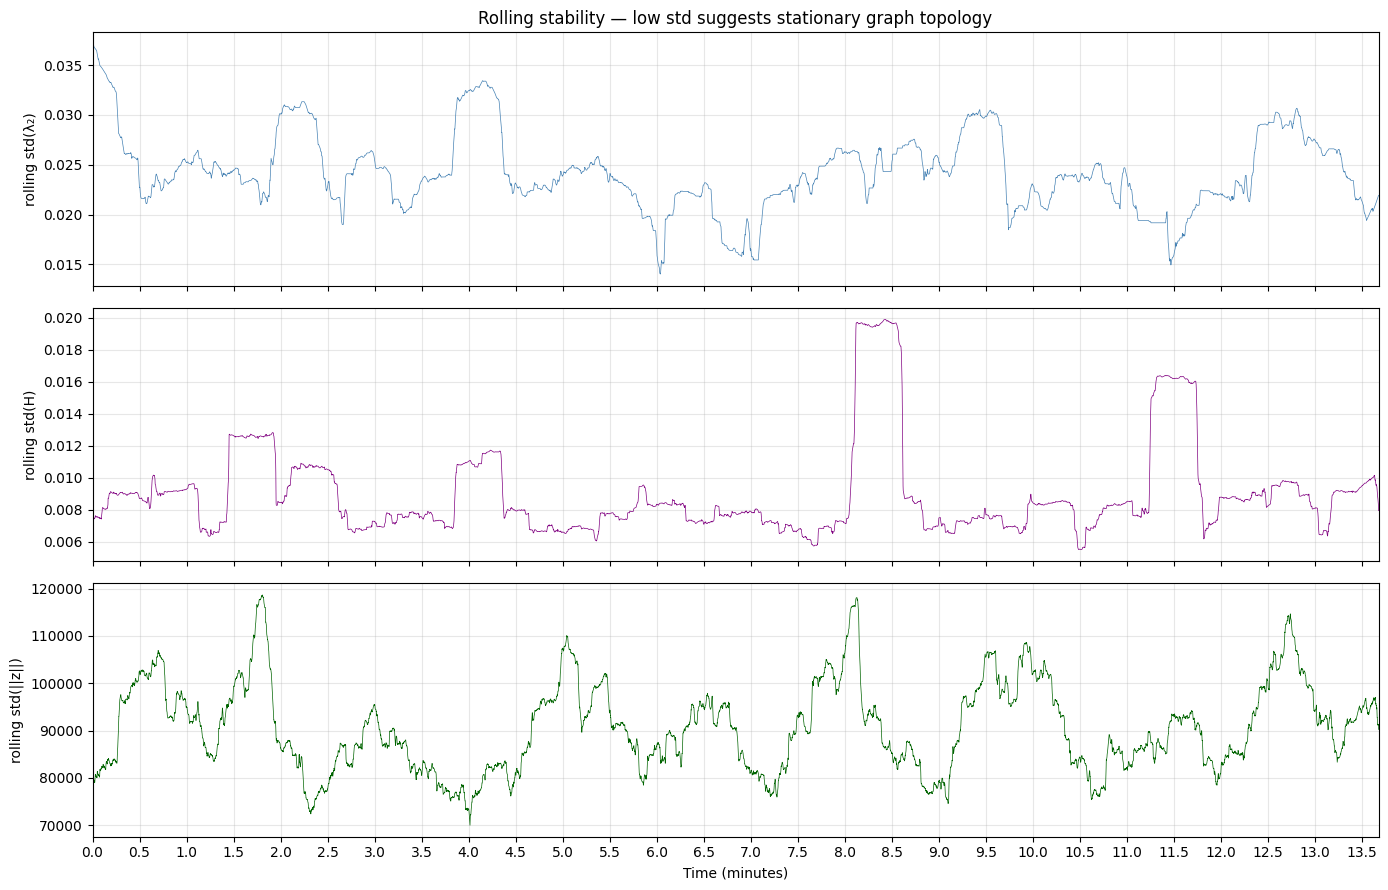

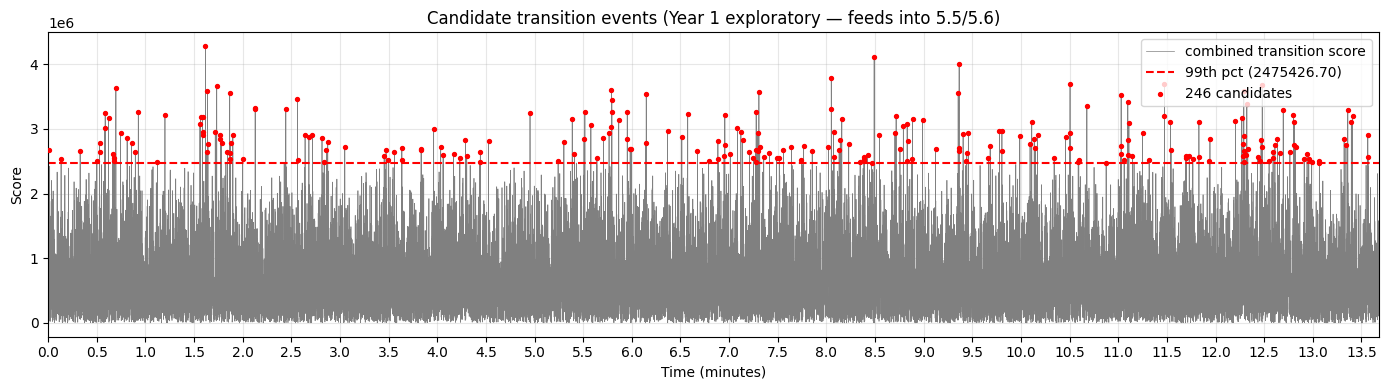

In [25]:
WINDOW = int(FPS * 30)  # 30-second rolling window

roll_lambda2 = rolling_std(lambda2, WINDOW)
roll_entropy = rolling_std(entropy, WINDOW)
z_norm = np.linalg.norm(np.where(np.isfinite(z), z, 0), axis=1)
roll_z = rolling_std(z_norm, WINDOW)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(time_s / 60, roll_lambda2, lw=0.5, color="steelblue")
axes[0].set_ylabel("rolling std(λ₂)")
axes[0].set_title("Rolling stability — low std suggests stationary graph topology")
axes[0].grid(alpha=0.3)

axes[1].plot(time_s / 60, roll_entropy, lw=0.5, color="purple")
axes[1].set_ylabel("rolling std(H)")
axes[1].grid(alpha=0.3)

axes[2].plot(time_s / 60, roll_z, lw=0.5, color="darkgreen")
axes[2].set_ylabel("rolling std(||z||)")
axes[2].set_xlabel("Time (minutes)")
axes[2].grid(alpha=0.3)

# Set x ticks to half a minute
start_min = (time_s[0] / 60)
end_min = (time_s[-1] / 60)
x_tick_spacing = 0.5  # half a minute
import numpy as np
xticks = np.arange(np.ceil(start_min / x_tick_spacing) * x_tick_spacing, end_min + x_tick_spacing, x_tick_spacing)
for ax in axes:
    ax.set_xticks(xticks)
    ax.set_xlim((start_min, end_min))

plt.tight_layout()
plt.show()

# Flag candidate transition frames (large simultaneous changes)
score = (
    np.abs(np.gradient(lambda2, dmd.dt))
    + np.abs(np.gradient(entropy, dmd.dt))
    + np.abs(np.gradient(z_norm, dmd.dt))
)
threshold = np.nanpercentile(score, 99)
candidates = np.where(score >= threshold)[0]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time_s / 60, score, lw=0.5, color="gray", label="combined transition score")
ax.axhline(threshold, color="red", ls="--", label=f"99th pct ({threshold:.2f})")
ax.scatter(time_s[candidates] / 60, score[candidates], c="red", s=8, zorder=5, label=f"{len(candidates)} candidates")
ax.set_xlabel("Time (minutes)")
ax.set_ylabel("Score")
ax.set_title("Candidate transition events (Year 1 exploratory — feeds into 5.5/5.6)")
ax.legend()
ax.grid(alpha=0.3)

# Set x ticks to half a minute for this plot too
ax.set_xticks(xticks)
ax.set_xlim((start_min, end_min))

plt.tight_layout()
plt.show()

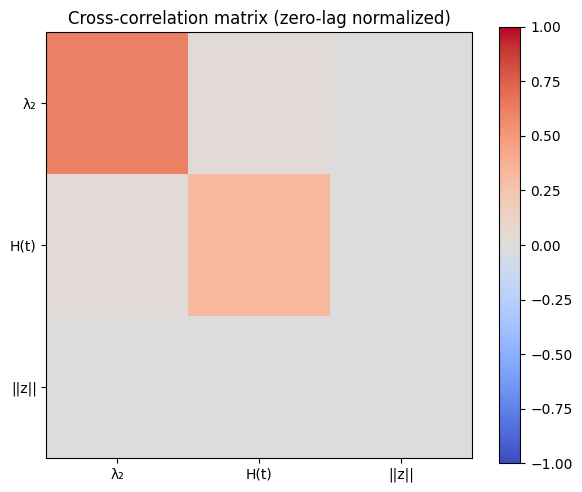


--- Year 1 quick stats ---
Frames: 24593, duration: 13.7 min
DMD reconstruction mean rel. error: 0.0117
Koopman one-step mean error: 33053.2243
Candidate transitions (99th pct): 246


In [26]:
# Cross-correlation between key scalar observables
from scipy.signal import correlate

scalars = {
    "λ₂": lambda2,
    "H(t)": entropy,
    "||z||": z_norm,
}
keys = list(scalars.keys())
n = len(keys)
corr_mat = np.zeros((n, n))
for i, ki in enumerate(keys):
    for j, kj in enumerate(keys):
        a = scalars[ki]
        b = scalars[kj]
        valid = np.isfinite(a) & np.isfinite(b)
        if valid.sum() < 10:
            continue
        c = correlate(a[valid] - np.mean(a[valid]), b[valid] - np.mean(b[valid]), mode="full")
        lag = np.argmax(c)
        corr_mat[i, j] = c[lag] / (np.linalg.norm(a[valid]) * np.linalg.norm(b[valid]) + 1e-12)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_mat, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(n), keys)
ax.set_yticks(range(n), keys)
ax.set_title("Cross-correlation matrix (zero-lag normalized)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("\n--- Year 1 quick stats ---")
print(f"Frames: {num_frames}, duration: {num_frames/FPS/60:.1f} min")
print(f"DMD reconstruction mean rel. error: {np.mean(rel_err):.4f}")
if koopman.one_step_prediction is not None and koopman.one_step_prediction.size:
    print(f"Koopman one-step mean error: {np.mean(step_err):.4f}")
print(f"Candidate transitions (99th pct): {len(candidates)}")

## Collective motion classification

Heuristic labels from raw `(x, y, vx, vy)` — traveling/polarized, milling, swarming, fountain evasion, and hydrodynamic sub-formations (in-line, phalanx, staggered).

Generate with: `python main.py motion -i <loc_vel_data.h5> -o results/<prefix> --fps 29.97`

In [ ]:
if motion is None:
    raise FileNotFoundError(f"Run motion classification first: python main.py motion -i ... -o {RESULTS_DIR}")

LABEL_COLORS = {
    "unknown": "#888888",
    "traveling_polarized": "#1f77b4",
    "milling": "#ff7f0e",
    "swarming": "#9467bd",
    "fountain_evasion": "#d62728",
    "hydrodynamic": "#2ca02c",
}

# Align motion length with spectral outputs if they differ slightly
T = min(len(motion.labels), num_frames)
t_min = time_s[:T] / 60
labels = motion.labels[:T]
hydro = motion.hydro_sub_labels[:T]
conf = motion.confidence[:T]

# --- Timeline strip ---
fig, ax = plt.subplots(figsize=(14, 2))
for label_id, name in enumerate(motion.label_names):
    mask = labels == label_id
    if not mask.any():
        continue
    ax.scatter(t_min[mask], np.full(mask.sum(), label_id), c=LABEL_COLORS.get(name, "gray"), s=1, label=name)
ax.set_yticks(range(len(motion.label_names)))
ax.set_yticklabels(motion.label_names)
ax.set_xlabel("Time (minutes)")
ax.set_title("Predicted collective motion over time")
ax.legend(loc="upper right", markerscale=4, framealpha=0.9)
plt.tight_layout()
plt.show()

# --- Category proportions ---
unique, counts = np.unique(labels, return_counts=True)
fig, ax = plt.subplots(figsize=(8, 4))
names = [motion.label_names[i] for i in unique]
colors = [LABEL_COLORS.get(n, "gray") for n in names]
ax.bar(names, counts / T, color=colors)
ax.set_ylabel("Fraction of frames")
ax.set_title("Motion category distribution")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

for i, n in zip(unique, counts):
    print(f"  {motion.label_names[i]}: {n} ({100*n/T:.1f}%)")

In [ ]:
# --- Motion vs spectral observables ---
lambda2 = graph.algebraic_connectivity[:T]
entropy = modal_entropy(dmd.modal_energies[:T])

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(t_min, lambda2, lw=0.4, color="steelblue")
axes[0].set_ylabel("λ₂")
axes[0].set_title("Spectral observables colored by motion (background)")

for label_id, name in enumerate(motion.label_names):
    mask = labels == label_id
    if mask.any():
        for ax in axes:
            ax.axvspan(t_min[mask][0], t_min[mask][-1], alpha=0.0)  # placeholder
        axes[0].fill_between(t_min, 0, 1, where=mask, transform=axes[0].get_xaxis_transform(),
                             alpha=0.08, color=LABEL_COLORS.get(name, "gray"))

axes[1].plot(t_min, entropy, lw=0.4, color="purple")
axes[1].set_ylabel("H(t)")

axes[2].plot(t_min, conf, lw=0.4, color="darkgreen")
axes[2].set_ylabel("confidence")
axes[2].set_xlabel("Time (minutes)")

plt.tight_layout()
plt.show()

# --- Feature heatmap (subsampled) ---
idx, feat_sub = subsample(motion.features[:T])
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(feat_sub.T, aspect="auto", origin="lower",
               extent=[t_min[idx[0]], t_min[idx[-1]], 0, len(motion.feature_names) - 1], cmap="coolwarm")
ax.set_yticks(range(len(motion.feature_names)), motion.feature_names)
ax.set_xlabel("Time (minutes)")
ax.set_title("Motion classifier features")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
from spectral.motion.labels import HydroSubLabel

hydro_mask = labels == motion.label_names.index("hydrodynamic")
if hydro_mask.any():
    hydro_ids = hydro[hydro_mask]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sub_counts = {HydroSubLabel.INLINE: 0, HydroSubLabel.PHALANX: 0, HydroSubLabel.STAGGERED: 0}
    for sub_id in hydro_ids:
        if sub_id in sub_counts:
            sub_counts[sub_id] += 1
    names = [motion.hydro_sub_label_names[list(HydroSubLabel).index(s)] for s in sub_counts]
    axes[0].bar(names, list(sub_counts.values()), color=["#2ca02c", "#98df8a", "#17becf"])
    axes[0].set_title("Hydrodynamic sub-formation counts")
    axes[0].set_ylabel("Frames")

    for sub in (HydroSubLabel.INLINE, HydroSubLabel.PHALANX, HydroSubLabel.STAGGERED):
        m = hydro_mask & (hydro == int(sub))
        if m.any():
            axes[1].scatter(
                t_min[m], np.full(m.sum(), int(sub)),
                s=2, label=motion.hydro_sub_label_names[list(HydroSubLabel).index(sub)],
            )
    axes[1].set_yticks([0, 1, 2], ["inline", "phalanx", "staggered"])
    axes[1].set_xlabel("Time (minutes)")
    axes[1].set_title("Hydrodynamic sub-formation timeline")
    axes[1].legend(markerscale=3)
    plt.tight_layout()
    plt.show()
else:
    print("No hydrodynamic frames detected — try tuning thresholds in MotionClassificationConfig")